# **Import Libraries and checking data info**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("CC GENERAL.csv")
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.shape

(8950, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


# **Feature Engineering**

In [7]:
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())

In [8]:
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())

In [9]:
((df["ONEOFF_PURCHASES"] == 0.00) & (df["INSTALLMENTS_PURCHASES"] == 0)).sum()

np.int64(2042)

In [10]:
df["CREDIT_LIMIT"].max()

30000.0

In [11]:
df["CREDIT_LIMIT"].min()

50.0

In [12]:
# Credit utilization :- Means How much of the available credit is being used.

df["Credit_Utilization"] = (df["BALANCE"]) / (df["CREDIT_LIMIT"] + 1)

In [13]:
# Payment Ratio :- Shows how aggressively a customer pays their balance.

df["Payment_Ratio"] = (df["PAYMENTS"]) / (df["BALANCE"] + 1)

In [14]:
# Full Payment Flag :- Customers who always pay in full often have different spending behavior.

df["Full_Payment_Flag"] = (df["PRC_FULL_PAYMENT"] == 1).astype(int)

In [15]:
# # One-off Purchase Ratio 
# Near 1 → mostly one-time purchases
# Near 0 → rarely buys expensive single items

df["ONEOFF_PURCHASES_RATIO"] = (df["ONEOFF_PURCHASES"]) / (df["PURCHASES"] + 1)

In [16]:
# Installment Ratio :- Shows preference for installment purchases.

df["Installment_Ratio"] = (df["INSTALLMENTS_PURCHASES"]) / (df["PURCHASES"] + 1)

In [17]:
# Cash Advance Ratio :- Measures reliance on cash advances.

df["Case_Advance_Ratio"] = (df["CASH_ADVANCE"]) / (df["CREDIT_LIMIT"] + 1)

In [18]:
# Average Purchase Amount

df["Average_Pruchage_Amount"] = (df["PURCHASES"]) / (df["PURCHASES_TRX"] + 1)

In [19]:
# Average Cash Advance :- Shows the average amount withdrawn each time.

df["Average_Case_Advance"] = (df["CASH_ADVANCE"]) / (df["CASH_ADVANCE_TRX"] + 1)

In [20]:
# Purchase Frequency per Month :- Normalizes spending by account age.

df["Purchase_per_month"] = (df["PURCHASES"]) / (df["TENURE"] + 1)

In [21]:
# Payment per Month

df["Payment_Per_Month"] = (df["PAYMENTS"]) / (df["TENURE"] + 1)

In [22]:
# Cash Advance Intensity :- Measures both amount and frequency of cash advances.

df["Case_Advance_Intensity"] = (df["CASH_ADVANCE"] * df["CASH_ADVANCE_FREQUENCY"]) 

In [23]:
# Balance-to-Purchase Ratio

df["Balance_Purchase_ratio"] = (df["BALANCE"]) / (df["PURCHASES"] + 1)

In [24]:
# Remaining Credit :- Shows unused credit available.

df["Remaining_Credit"] = df["CREDIT_LIMIT"] - df["BALANCE"]

In [25]:
# Cash Advance User Flag

df["Used_Cash_Advance"] = (df["CASH_ADVANCE"] > 0).astype(int)

In [26]:
# One-off Buyer Flag

df["Used_OneOff"] = (df["ONEOFF_PURCHASES"] > 0).astype(int)

In [27]:
# Installment Buyer Flag

df["Used_Installment"] = (df["INSTALLMENTS_PURCHASES"] > 0).astype(int)

# **Checking Correlation and Drop Columns**

In [28]:
col = ["CUST_ID", "PRC_FULL_PAYMENT"]

comb_col = ["PURCHASES", "PAYMENTS", "PURCHASES_TRX", "CASH_ADVANCE_TRX", "TENURE", "PURCHASES_FREQUENCY",
            "CASH_ADVANCE_FREQUENCY"]

drop_col = col + comb_col

df_clean = df.drop(columns=drop_col)

In [29]:
df_clean.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CREDIT_LIMIT', 'MINIMUM_PAYMENTS',
       'Credit_Utilization', 'Payment_Ratio', 'Full_Payment_Flag',
       'ONEOFF_PURCHASES_RATIO', 'Installment_Ratio', 'Case_Advance_Ratio',
       'Average_Pruchage_Amount', 'Average_Case_Advance', 'Purchase_per_month',
       'Payment_Per_Month', 'Case_Advance_Intensity', 'Balance_Purchase_ratio',
       'Remaining_Credit', 'Used_Cash_Advance', 'Used_OneOff',
       'Used_Installment'],
      dtype='object')

* **Outliers**

In [30]:
# IQR

Q1 = df_clean.quantile(0.25)
Q3 = df_clean.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = ((df_clean < lower) | (df_clean > upper))

outliers.sum()

BALANCE                              695
BALANCE_FREQUENCY                   1493
ONEOFF_PURCHASES                    1013
INSTALLMENTS_PURCHASES               867
CASH_ADVANCE                        1030
ONEOFF_PURCHASES_FREQUENCY           782
PURCHASES_INSTALLMENTS_FREQUENCY       0
CREDIT_LIMIT                         248
MINIMUM_PAYMENTS                     909
Credit_Utilization                     3
Payment_Ratio                        787
Full_Payment_Flag                    488
ONEOFF_PURCHASES_RATIO                 0
Installment_Ratio                      3
Case_Advance_Ratio                   822
Average_Pruchage_Amount              568
Average_Case_Advance                 797
Purchase_per_month                   786
Payment_Per_Month                    818
Case_Advance_Intensity              1466
Balance_Purchase_ratio              1997
Remaining_Credit                     351
Used_Cash_Advance                      0
Used_OneOff                            0
Used_Installment

In [31]:
df_clean["Balance_Purchase_ratio"].describe()

count     8950.000000
mean       496.145654
std       1356.829331
min          0.000000
25%          0.149758
50%          1.447522
75%         23.593461
max      14581.459140
Name: Balance_Purchase_ratio, dtype: float64

<Axes: >

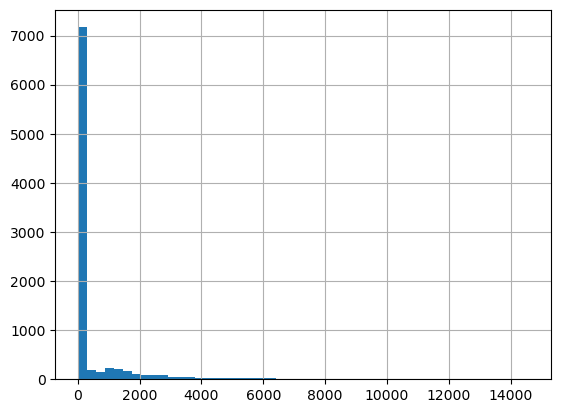

In [32]:
df_clean["Balance_Purchase_ratio"].hist(bins=50)

In [33]:
import numpy as np

df_clean["Balance_Purchase_ratio"] = np.log1p(df_clean["Balance_Purchase_ratio"])

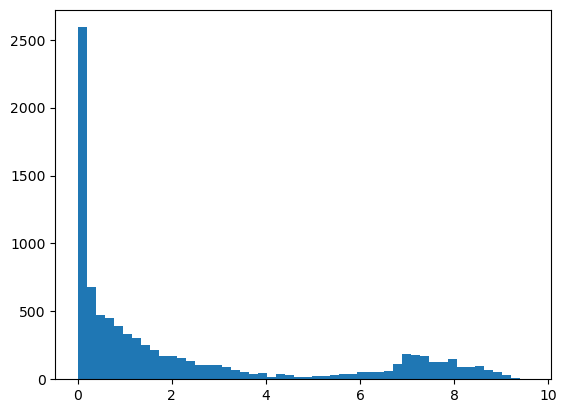

In [34]:
plt.hist(df_clean["Balance_Purchase_ratio"], bins=50)
plt.show()

In [35]:
outliers = ((df_clean < lower) | (df_clean > upper))

outliers.sum()

BALANCE                              695
BALANCE_FREQUENCY                   1493
ONEOFF_PURCHASES                    1013
INSTALLMENTS_PURCHASES               867
CASH_ADVANCE                        1030
ONEOFF_PURCHASES_FREQUENCY           782
PURCHASES_INSTALLMENTS_FREQUENCY       0
CREDIT_LIMIT                         248
MINIMUM_PAYMENTS                     909
Credit_Utilization                     3
Payment_Ratio                        787
Full_Payment_Flag                    488
ONEOFF_PURCHASES_RATIO                 0
Installment_Ratio                      3
Case_Advance_Ratio                   822
Average_Pruchage_Amount              568
Average_Case_Advance                 797
Purchase_per_month                   786
Payment_Per_Month                    818
Case_Advance_Intensity              1466
Balance_Purchase_ratio                 0
Remaining_Credit                     351
Used_Cash_Advance                      0
Used_OneOff                            0
Used_Installment

In [36]:
Q1 = df_clean["Balance_Purchase_ratio"].quantile(0.25)
Q3 = df_clean["Balance_Purchase_ratio"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_final = df_clean[
    (df_clean["Balance_Purchase_ratio"] >= lower) &
    (df_clean["Balance_Purchase_ratio"] <= upper)
]

In [37]:
df_clean["CREDIT_LIMIT"].describe()

count     8950.000000
mean      4494.282473
std       3638.646702
min         50.000000
25%       1600.000000
50%       3000.000000
75%       6500.000000
max      30000.000000
Name: CREDIT_LIMIT, dtype: float64

In [38]:
df_final[["BALANCE", "Credit_Utilization", "Remaining_Credit"]].corr()

,BALANCE,Credit_Utilization,Remaining_Credit
BALANCE,1.000000,0.479063,-0.035108
Credit_Utilization,0.479063,1.000000,-0.483151
Remaining_Credit,-0.035108,-0.483151,1.000000


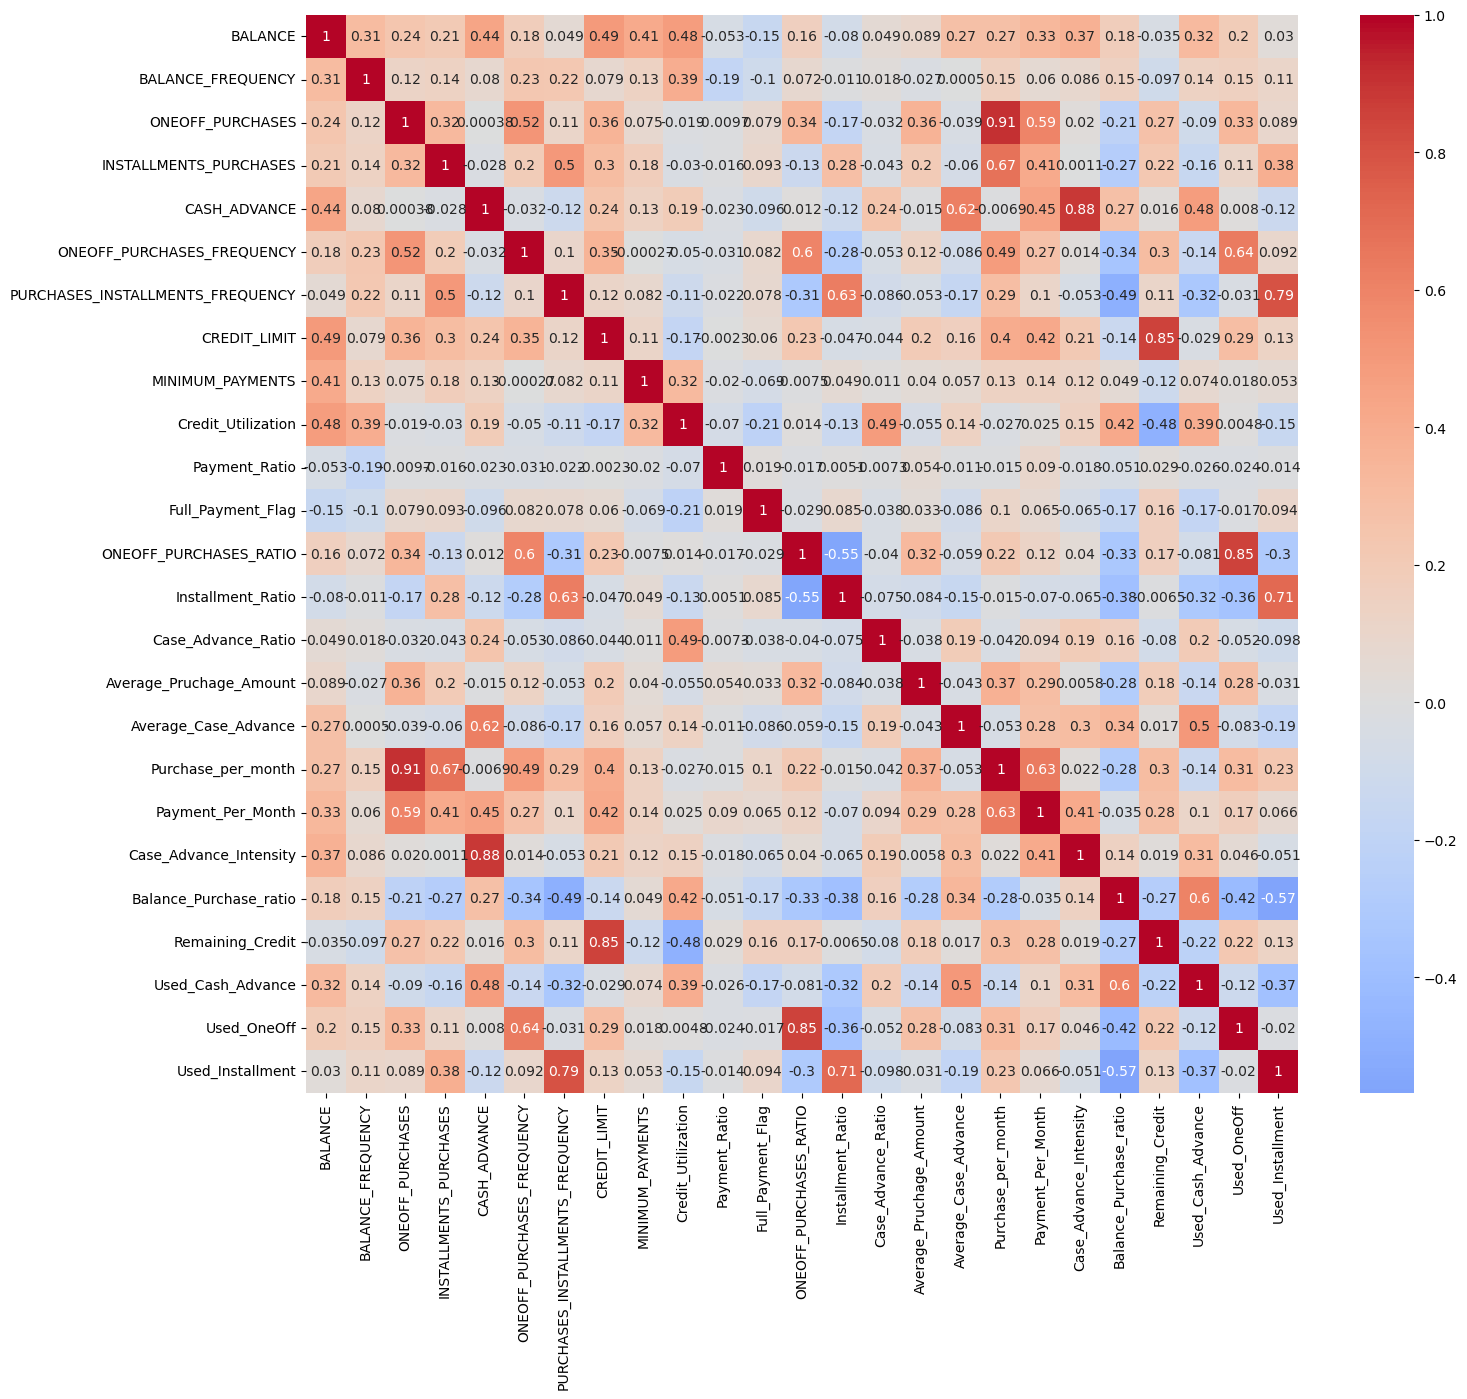

In [39]:
plt.figure(figsize=(16, 14))
sns.heatmap(df_final.corr(numeric_only=True), cmap="coolwarm", center=0, annot=True)
plt.show()

# **Scaling**

In [40]:
from sklearn.preprocessing import StandardScaler

X = df_final

In [77]:
df_final.columns

Index(['BALANCE', 'BALANCE_FREQUENCY', 'ONEOFF_PURCHASES',
       'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'ONEOFF_PURCHASES_FREQUENCY',
       'PURCHASES_INSTALLMENTS_FREQUENCY', 'CREDIT_LIMIT', 'MINIMUM_PAYMENTS',
       'Credit_Utilization', 'Payment_Ratio', 'Full_Payment_Flag',
       'ONEOFF_PURCHASES_RATIO', 'Installment_Ratio', 'Case_Advance_Ratio',
       'Average_Pruchage_Amount', 'Average_Case_Advance', 'Purchase_per_month',
       'Payment_Per_Month', 'Case_Advance_Intensity', 'Balance_Purchase_ratio',
       'Remaining_Credit', 'Used_Cash_Advance', 'Used_OneOff',
       'Used_Installment', 'cluster'],
      dtype='object')

In [41]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# **Visualization**

In [42]:
from sklearn.decomposition import PCA

In [43]:
pca = PCA(n_components=13)

X_pca = pca.fit_transform(X_scaled)

In [44]:
pca.explained_variance_ratio_

array([0.19482024, 0.16813666, 0.11993256, 0.08162855, 0.05859981,
       0.04967702, 0.04425972, 0.03933166, 0.03668118, 0.03594994,
       0.02905943, 0.02801083, 0.02202696])

Text(0.5, 0.92, '3d projection')

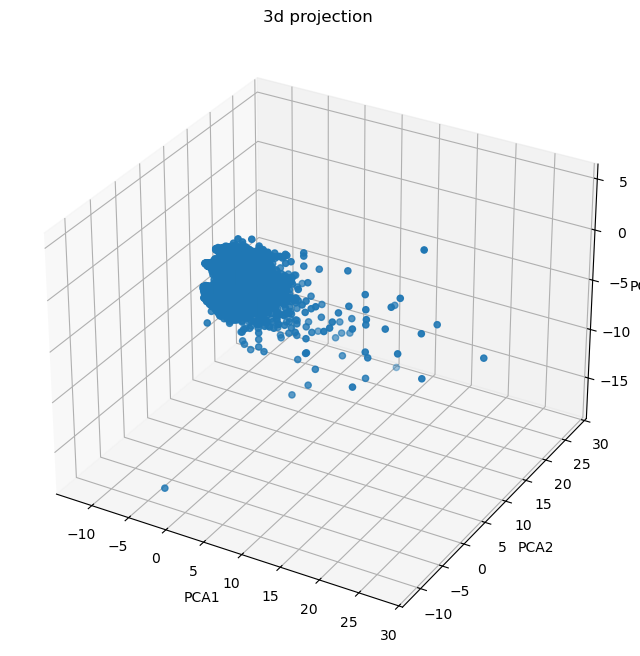

In [45]:
fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# **Analyze K value**

In [46]:
# Elbow method

from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

knee = KneeLocator(range(1, 10), wcss, curve="convex", direction="decreasing")
k = knee.elbow
print(k)

5


Text(0, 0.5, 'Silhouette score')

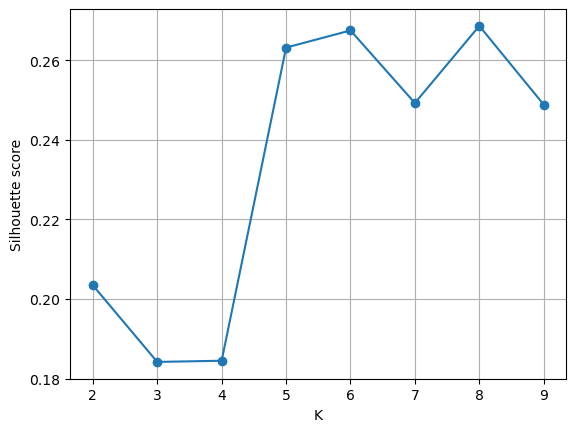

In [47]:
# Silhouette Score

from sklearn.metrics import silhouette_score

scores = []

for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

plt.plot(range(2, 10), scores, marker = "o")
plt.grid()
plt.xlabel("K")
plt.ylabel("Silhouette score")

# **Clustering**

In [48]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

Text(0.5, 0.92, '3d projection')

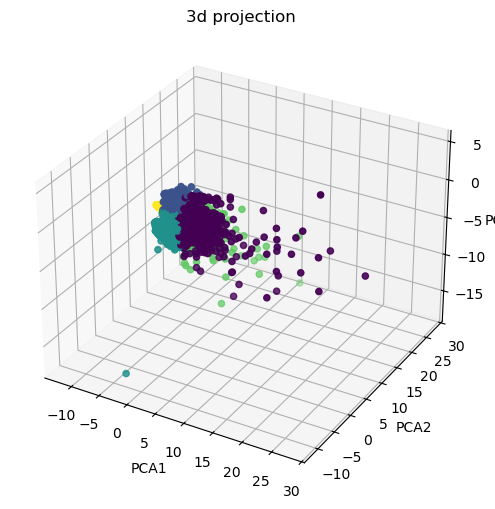

In [49]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

In [50]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

In [51]:
agg_clf = AgglomerativeClustering(n_clusters=5, linkage="ward")
agg_labels = agg_clf.fit_predict(X_pca)

Text(0.5, 0.92, '3d projection')

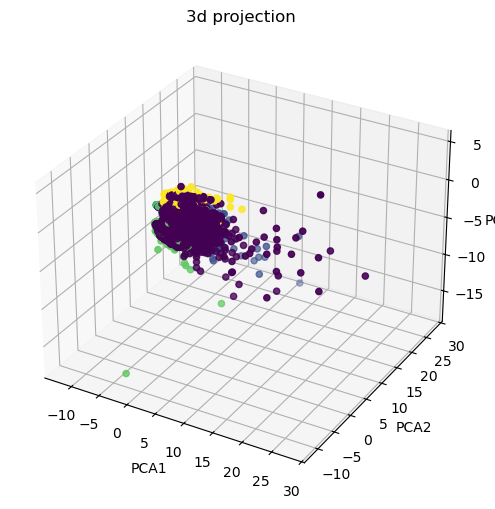

In [52]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=agg_labels)
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

* **Choosing Model**

In [70]:
kmeans_score = silhouette_score(X_pca, labels_kmeans)
print("KMeans:", kmeans_score)

KMeans: 0.263192353467251


In [71]:
agg_score = silhouette_score(X_pca, agg_labels)
print("Agglomerative:", agg_score)

Agglomerative: 0.20492971176109587


* KMeans win , KMeans got higher silhouette score

# **Characterization Of Clusters**

In [72]:
X["cluster"] = labels_kmeans

C:\Users\prita\AppData\Local\Temp\ipykernel_21836\1365601994.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["cluster"] = labels_kmeans


In [73]:
X.head()

,BALANCE,BALANCE_FREQUENCY,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CREDIT_LIMIT,MINIMUM_PAYMENTS,Credit_Utilization,...,Average_Case_Advance,Purchase_per_month,Payment_Per_Month,Case_Advance_Intensity,Balance_Purchase_ratio,Remaining_Credit,Used_Cash_Advance,Used_OneOff,Used_Installment,cluster
0,40.900749,0.818182,0.00,95.40,0.000000,0.000000,0.083333,1000.0,139.509787,0.040860,...,0.000000,7.338462,15.523237,0.000000,0.353668,959.099251,0,0,1,2
2,2495.148862,1.000000,773.17,0.00,0.000000,1.000000,0.000000,7500.0,627.284787,0.332642,...,0.000000,59.474615,47.851288,0.000000,1.440545,5004.851138,0,1,0,1
3,1666.670542,0.636364,1499.00,0.00,205.788017,0.083333,0.000000,7500.0,312.343947,0.222193,...,102.894008,115.307692,0.000000,17.148933,0.747216,5833.329458,1,1,0,1
4,817.714335,1.000000,16.00,0.00,0.000000,0.083333,0.000000,1200.0,244.791237,0.680861,...,0.000000,1.230769,52.179597,0.000000,3.893876,382.285665,0,1,0,1
5,1809.828751,1.000000,0.00,1333.28,0.000000,0.000000,0.583333,1800.0,2407.246035,1.004902,...,0.000000,102.560000,107.696752,0.000000,0.857139,-9.828751,0,0,1,2


C:\Users\prita\AppData\Local\Temp\ipykernel_21836\4136905658.py:3: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.countplot(x=X["cluster"], palette=color, hue=X["cluster"])


<Axes: xlabel='cluster', ylabel='count'>

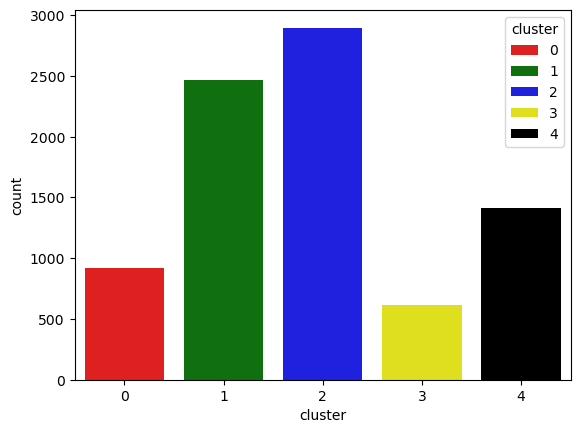

In [74]:
color = ["red", "green", "blue", "yellow", "black", "gray"]

sns.countplot(x=X["cluster"], palette=color, hue=X["cluster"])

In [75]:
# Cluster Summary

cluster_summery = X.groupby("cluster").mean()
print(cluster_summery)

             BALANCE  BALANCE_FREQUENCY  ONEOFF_PURCHASES  \
cluster                                                     
0        2102.599804           0.968805       3117.915846   
1        1052.671173           0.856850        709.883457   
2         624.397418           0.840840         75.226457   
3        5192.613280           0.966524        747.533042   
4        1047.228152           0.841016          0.022447   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  ONEOFF_PURCHASES_FREQUENCY  \
cluster                                                                     
0                   1625.311323    228.295372                    0.682621   
1                     88.712161    376.604671                    0.353675   
2                    556.776043    181.285685                    0.051923   
3                    563.905615   5122.909980                    0.260107   
4                      0.795615   1246.167357                    0.000477   

         PURCHASES_INSTALLMENTS_

# **Saving model**

In [76]:
import joblib

# Save trained objects
joblib.dump(kmeans, "model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")

# Save feature order
joblib.dump(df_clean.columns.tolist(), "feature_order.pkl")

print("Model exported successfully!")

Model exported successfully!
